<a href="https://colab.research.google.com/github/kimzwegz/tpq_project/blob/main/tpq_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone the GitHub repository that contains all project code and resources.
!git clone https://github.com/kimzwegz/tpq_project.git

# Install required Python package for connecting to SQL databases (optional, used if connecting to a database via ODBC).
!pip install pyodbc

# Install MLflow for experiment tracking and model versioning.
!pip install mlflow

# Change the working directory to the cloned project folder so that relative file paths work properly.
%cd /content/tpq_project

# Add the project directory to Python's module search path to allow importing local modules and packages.
import sys
sys.path.append('/content/tpq_project')

# Import Colab/Notebook display tools for showing HTML text and images in output cells.
from IPython.display import Image, display, HTML

# IMPORTANT: If this is your first time running the notebook or after installing packages,
# you may need to restart the runtime session for everything to load properly.
# After restarting, re-run the notebook from the beginning.

display(HTML("<b style='color:red;'>📌 Please restart the Colab runtime (Runtime > Restart runtime) and then re-run the notebook to apply all changes.</b>"))


Cloning into 'tpq_project'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 213 (delta 32), reused 12 (delta 3), pack-reused 166 (from 1)
Receiving objects: 100% (213/213), 38.78 MiB | 11.73 MiB/s, done.
Resolving deltas: 100% (140/140), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.0/354.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.9/705.9 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

<h1 style="text-align: center;"><b><u>Mitigating Overfitting in Hyperparameter Selection for Trading Strategies Using Randomized In-Sample Evaluation</u></b></h1>


<p> <b> May 20, 2025 </p>

<h2 style="text-align: Center;"><b>Abstract</b></h2>


<p> In quantitative finance and algorithmic trading, hyperparameter tuning is often performed via a traditional train-test split, with the best-performing model on the in-sample data evaluated on a holdout set. However, this approach is prone to overfitting, particularly when evaluating a large grid of parameters, as it optimizes to a single realization of the in-sample period. In this study, we propose a robust method to reduce overfitting by introducing randomized subsampling within the in-sample (training) data. Instead of selecting hyperparameters based solely on performance over a single in-sample period, we compute <b><i>pooled</i></b> Sharpe ratios from multiple random samples of the training set. The hyperparameters with the highest <b><i>pooled</i></b> Sharpe ratio are then tested on the out-of-sample data. We empirically compare this method to the classic approach across a large grid of strategy parameters. Using statistical testing on the ranks of parameter performance, we show that our method yields lower rank divergence between in-sample and out-of-sample performance, indicating a more stable and less overfit model selection process. This framework offers a practical enhancement to hyperparameter selection workflows in trading strategy development. </p>


<h2 style="text-align: Center;"><b>Literature Review</b></h2>

<p> Traditional approaches to model evaluation in financial machine learning often rely on train-test splits,
where hyperparameters are selected based on in-sample performance and then validated out-of-sample (Bailey et al., 2014; López de Prado, 2018). However, this method can lead to overfitting, especially when extensive grid searches are used, as it capitalizes on noise within the in-sample period. Various techniques, such as cross-validation and nested cross-validation (Varma & Simon, 2006), have been proposed to mitigate this, though they are less commonly adopted in time-series settings due to data dependencies. To improve robustness, some studies advocate for performance aggregation methods across multiple subsamples (Hansen & Lunde, 2005). In particular, pooling performance metrics like the Sharpe ratio across random subsamples provides a more stable estimator of a strategy’s risk-adjusted return by incorporating variability across multiple data slices (Ledoit & Wolf, 2008). Despite its statistical rigor, pooled Sharpe ratio estimation is underutilized in hyperparameter selection frameworks, motivating its integration into a more robust model selection process. </p>


<h2 style="text-align: Center;"><b>Data</b></h2>

<p> This study utilizes a dataset comprising 22 Contract for Difference (CFD) instruments sourced from OANDA, a reputable provider of retail trading data. The dataset spans a five-year period from 2000 to 2004, with a temporal resolution of one hour. After removing incomplete records, the total number of observations across all instruments is 604,321.
Each CFD instrument is individually processed, with its time series divided into an in-sample set (80%) used for model selection and training, and an out-of-sample set (20%) reserved strictly for performance evaluation. To mitigate overfitting during hyperparameter selection, the in-sample data is further subjected to randomized subsampling, where 80% of the in-sample data is randomly shuffled 10 folds each fold is also 80% of the entire insample size. Performance metrics, particularly the Sharpe ratio, are aggregated across these subsamples to compute a pooled estimate, which informs parameter selection. This hierarchical splitting structure allows for a robust assessment of the proposed method’s ability to generalize beyond the specific training realizations.

<h2 style="text-align: Center;"><b>Methodology</b></h2>

<h3>Modified MACD Strategy</h3>

<p>
The strategy utilized is the traditional Moving Average Convergence Divergence (MACD) indicator for trend-following, where positions are determined based on the relative strength of the trend. Rather than issuing discrete buy/sell signals, the strategy uses a continuous exposure derived from a normalized-zero-to-one vector for positive MACD histogram values and a normalized-zero-to-negative-one vector for negative values.
</p>

<div style="text-align: center;">
  <img src="https://github.com/kimzwegz/tpq_project/blob/main/images/macd.png?raw=1" alt="Normalized MACD Position Formula" width="600">
</div>


<h3>1. Simple In/Out Sample Splits Evaluation</h3>

<p> To evaluate the robustness of hyperparameter selection in the presence of potential overfitting, we adopt a structured experiment design applied to each of the 22 CFD instruments individually. The dataset for each instrument is split chronologically into two subsets:
In-sample (Training): 80% of the data
Out-of-sample (Testing): 20% of the data
On the in-sample portion, we perform a grid search over a set of hyperparameters for a modified MACD-based trend-following strategy (details provided in a later section). For each parameter combination, we compute the Sharpe ratio and use it to rank the strategies based on their in-sample performance in ascending order where the highest performer would get the highest rank.
Once the best-performing parameters are identified from the in-sample data, we evaluate them on the out-of-sample data using the same Sharpe ratio metric. To measure the consistency of performance, we calculate the absolute value of rank delta—the change in ranking between in-sample and out-of-sample performance—for each parameter set. This rank delta serves as a proxy for the degree of overfitting: large shifts suggest over-optimized parameters that fail to generalize.
</p>

<div style="text-align: center;">
  <img src="https://github.com/kimzwegz/tpq_project/blob/main/images/sample_split1.png?raw=1" alt="Pooled Sharpe Ratio Formula" width="600">
</div>



<h3>2. Randomized In/Out Sample Splits Evaluation</h3>

<p>
To enhance the robustness of hyperparameter selection and mitigate overfitting to a single in-sample partition, the in-sample set (80% of the original data) is further subjected to randomized subsampling. Specifically, for each instrument, we perform <b>10 random shuffles</b>, each selecting a random <b>80% subset</b> of the original in-sample data. On each of these randomized folds, the same hyperparameter grid search is executed using a modified MACD trend-following strategy.
</p>

<p>
For every parameter combination evaluated across the folds, we compute the Sharpe ratio based on each fold's return and standard deviation. These Sharpe ratios are then aggregated across the 10 folds using a <b>pooled estimation approach</b>, which accounts for both the weighted average return and the pooled standard deviation.
</p>

<div style="text-align: center;">
  <img src="https://github.com/kimzwegz/tpq_project/blob/main/images/sample_split2.png?raw=1" alt="Pooled Sharpe Ratio Formula" width="600">
</div>





<h3> Pooled Sharpe Ratio Calculation</h3>


<p>
This pooled Sharpe ratio provides a more stable estimate of each parameter combination's performance across multiple randomizations of the in-sample data. After calculating the pooled Sharpe for all parameter sets, we rank them in descending order. This ranking forms the basis for comparison with the out-of-sample performance rankings.
</p>

<div style="text-align: center;">
  <img src="https://github.com/kimzwegz/tpq_project/blob/main/images/pooled_sharpe.png?raw=1" alt="Pooled Sharpe Ratio Formula" width="600">
</div>


<h2 style="text-align: Center;"><b>Conclusion</b></h2>

<p>
The comparative analysis of strategy generalization under simple versus randomized in-sample evaluation reveals meaningful insights into overfitting risk and parameter stability.
While the average out-of-sample return differences were not statistically distinguishable between methods, the randomized selection procedure exhibited a significantly lower rank degradation.
This indicates a stronger preservation of performance orderings when transitioning from in-sample to out-of-sample environments—an essential quality in robust trading strategy design.
</p>

<p>
These results suggest that although return magnitudes may be affected by exogenous market dynamics (e.g., trend absence), ranking consistency provides a more reliable indicator of model generalization.
Accordingly, the following implementation leverages randomized subsampling to mitigate overfitting and improve parameter selection robustness across varying market conditions.
</p>


<h2 style="text-align: Center;"><b>References</b></h2>

<ol>
  <li>
    Bailey, D. H., Borwein, J. M., López de Prado, M., & Zhu, Q. J. (2017).
    <i>The probability of backtest overfitting</i>.
    <i>The Journal of Computational Finance</i>, 20(4), 39–69.
  </li>
  <li>
    López de Prado, M. (2018).
    <i>Advances in Financial Machine Learning</i>.
    John Wiley & Sons.
  </li>
  <li>
    Varma, S., & Simon, R. (2006).
    Bias in error estimation when using cross-validation for model selection.
    <i>BMC Bioinformatics</i>, 7(1), 91.
  </li>
  <li>
    Hansen, P. R., & Lunde, A. (2005).
    Forecast evaluation and combination. In G. Elliott, C. W. J. Granger, & A. Timmermann (Eds.),
    <i>Handbook of Economic Forecasting</i> (Vol. 1, pp. 285–330). Elsevier.
  </li>
  <li>
    Ledoit, O., & Wolf, M. (2008).
    Robust performance hypothesis testing with the Sharpe ratio.
    <i>Journal of Empirical Finance</i>, 15(5), 850–859.
  </li>
</ol>

<hr>
<h2 style="text-align: Center;"><b>Python Implementation</b></h2>

<h3 style="text-align: left;"><b> Module imports </b></h3>

<p/> Importing internal and external packages and setting up the notebook to display results </p>

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import logging
import warnings
from backtest import BackTest

plt.style.use('ggplot')
logging.basicConfig(level=logging.INFO)
pd.set_option('display.max_columns', 500)
warnings.filterwarnings("ignore")
%matplotlib inline

/content/tpq_project/utils/utils.py:1180: SyntaxWarning: invalid escape sequence '\k'
  >>> file:///e:\khalilk\development\mlruns
/content/tpq_project/utils/utils.py:1870: SyntaxWarning: invalid escape sequence '\k'
  >>> file:///e:\khalilk\development\mlruns


In [3]:
# Initialize BackTest instance.
bt = BackTest()

Instruments loaded: 22
 ['JP225_USD', 'WHEAT_USD', 'USB10Y_USD', 'NATGAS_USD', 'BCO_USD', 'WTICO_USD', 'XCU_USD', 'XAG_USD', 'SPX500_USD', 'CORN_USD', 'CN50_USD', 'US2000_USD', 'USB05Y_USD', 'XPT_USD', 'US30_USD', 'USB30Y_USD', 'SUGAR_USD', 'SOYBN_USD', 'NAS100_USD', 'XAU_USD', 'XPD_USD', 'USB02Y_USD']


<hr>
<h3 style="text-align: left;"><b> Data </b></h3>

<h4><u><b>Figure</b>: Data Availability</u></h4>


<p>
The <b>stacked bar chart</b> (top-left) visualizes the year-wise contribution of each instrument's data volume. This provides insight into how data availability fluctuates across years and instruments. Instruments with consistent availability across all years appear as uniform bands, while those with data gaps or later introductions show visible drops or truncated bars.
</p>

<p>
The <b>bar chart</b> on the top-right quantifies the total number of observations available for each instrument across all years. This highlights which instruments contribute the most (e.g., major indices like JP225, SPX500, and NAS100) and those with relatively lower participation (e.g., soft commodities or shorter history instruments).
</p>

<p>
The <b>area chart</b> (bottom-left) offers a cumulative view of instrument data volume per year. This highlights broader trends such as overall data coverage growth, attrition, or plateaus in availability, helping assess the balance and distribution of the dataset.
</p>

<p>
The final <b>line plot</b> (bottom-right) tracks the yearly total number of hourly observations, summing across all instruments. This gives a high-level overview of the annual data density and consistency of the full panel.
</p>

<p>
Together, these visualizations confirm that the dataset is sufficiently deep and broad across both time and instruments, supporting the robustness of the randomized and pooled backtesting analysis that follows.

</p>

<p>
<br>
<i> for detailed information please refer to the appendix 1</i>

</p>



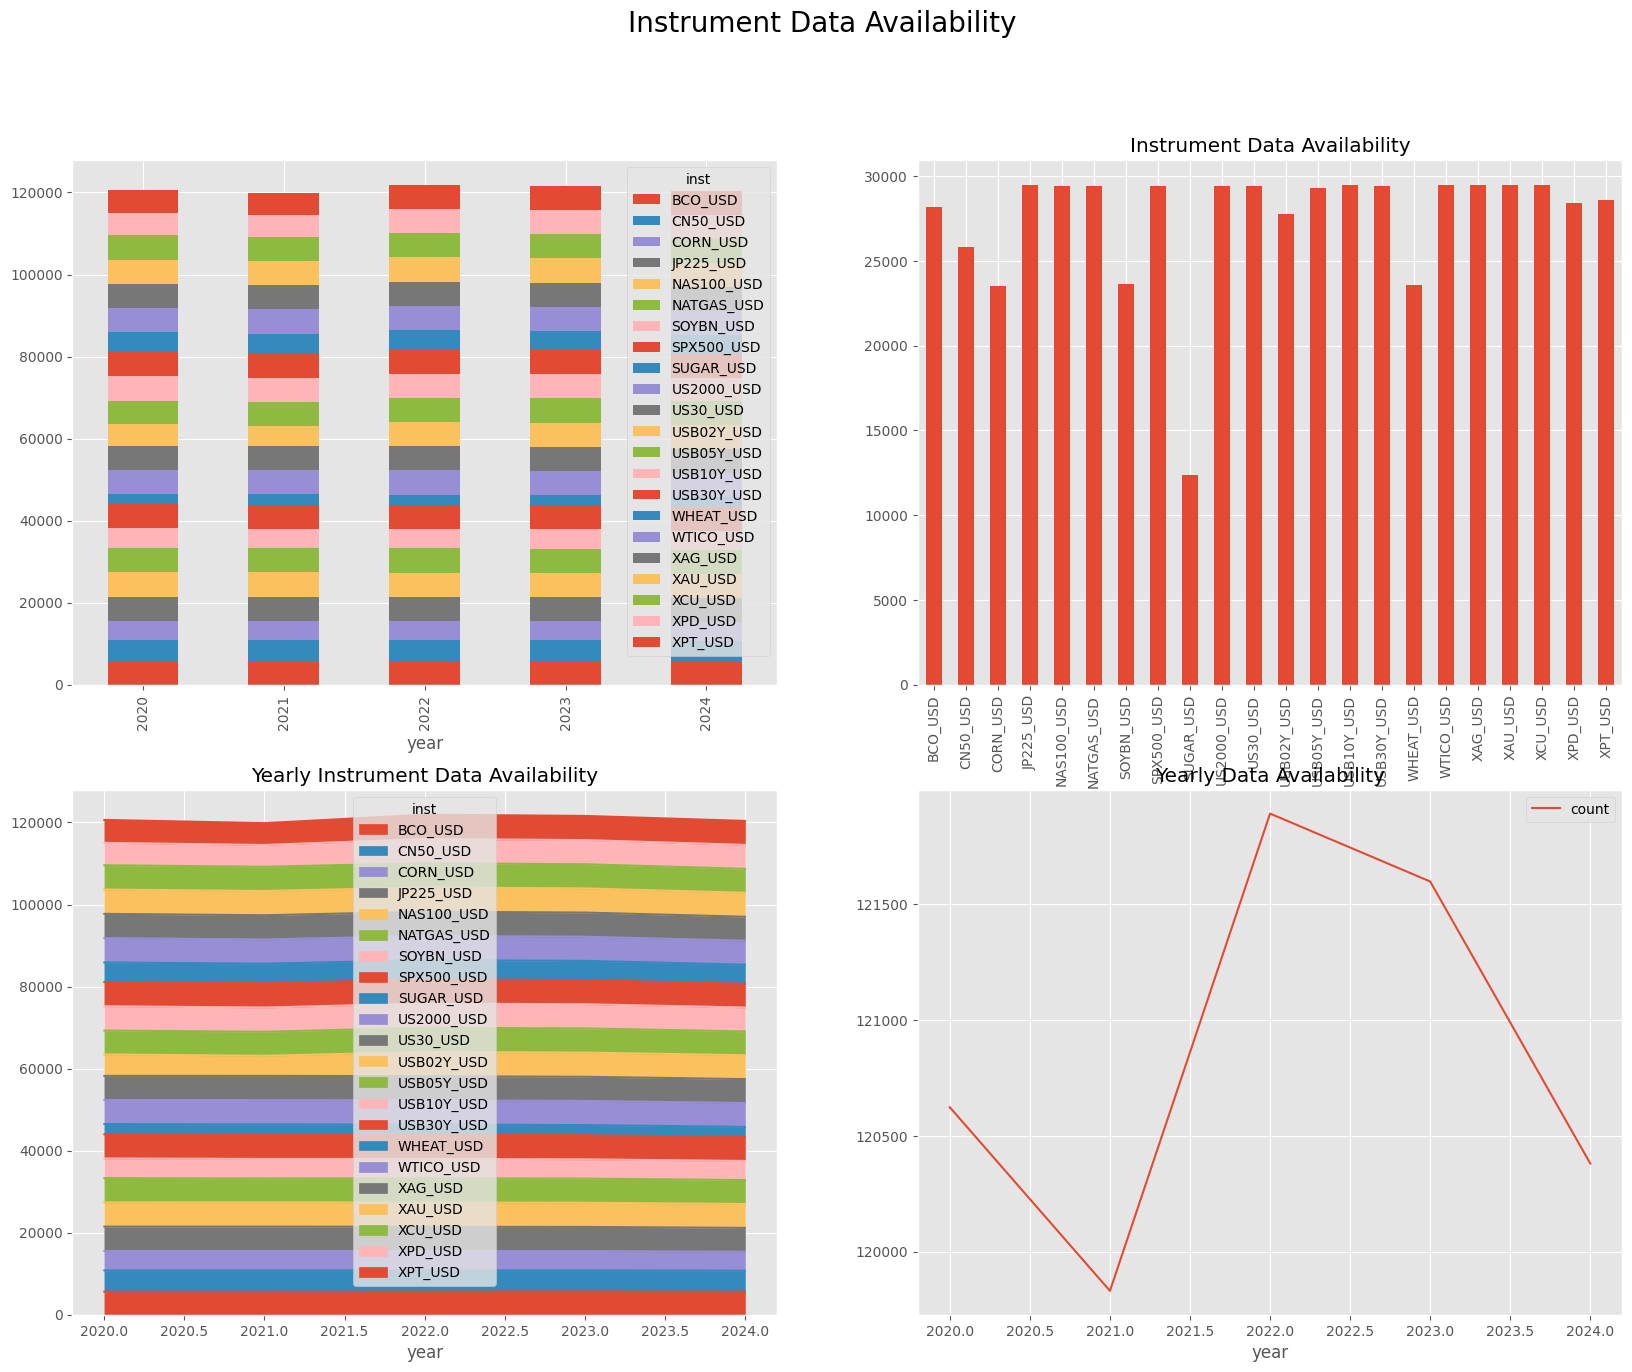

In [4]:
_ = bt.plot_data()

<hr>
<h3 style="text-align: left;"><b> Backtest </b></h3>

<h4>Full Backtest Execution Loop for All Instruments</h4>

<p>
This block of code executes the entire backtesting pipeline for all instruments in the dataset.
<br>
<br>
For each instrument:
<ol>
<li> Loads the historical data,
<li> Defines a grid of MACD hyperparameters, and
<li> Runs a brute-force grid search to evaluate strategy performance on three data partitions: <b>in-sample</b> (80%), <b>out-of-sample</b> (20%), and <b>full-sample</b> (100%).
<br> <br>
<b> <u> Grid search: </u></b>
The function implements a brute force grid search over a specified range of MACD parameters (short EMA, long EMA, and signal EMA) for a given instrument. The strategy logic is encapsulated in the <code>MACD</code> class, which handles the instantiation, backtesting, and metric extraction process. The backtest results, including the Sharpe ratio and other statistics for each parameter combination, are compiled and returned as a DataFrame. Each result is tagged with the instrument and the corresponding parameter set. Each result is saved into an HDF5 file using an appropriate key (e.g., 'in', 'out', 'all').
</p>

<li> <b>Randomized in-sample backtests</b> by drawing multiple overlapping 80% windows from the in-sample data and re-running the MACD grid search on each fold. This approach supports robust evaluation and helps to detect parameter sets that generalize well across varying sample windows. All results are stored in a single HDF5 file per instrument, enabling unified post-analysis.
</p>


<b> <u> Randomized In-Sample Grid Search: </u> </b>
This function extends the brute-force MACD grid search by applying it across <b>multiple randomized in-sample subsets</b> of a given instrument's data. It simulates variability in training data by randomly selecting multiple (e.g., 10) time-based folds from the in-sample period. For each random sample, the MACD grid search is performed using the <code>run_backtest</code> function, and the results are stored. The goal of this approach is to evaluate the stability and robustness of MACD parameter configurations across different market environments, using pooled performance metrics such as the aggregated Sharpe ratio. This technique helps minimize overfitting to a single slice of data and supports more generalizable parameter selection.

<li>Saves the results of the backtest into an HDF file with under the appropriate key: 'in' for the insample backtest, 'out' for the out of sample backtest and 'rand' for the 'randomized' backtest.
</p>

In [5]:
# ## THIS BLOCK TAKES APROX 160 minutes to run on a 4-core CPU with 32GB RAM
# ## THE SCRIPT SAVES THE RESULTS IN A PARQUET FILE FOR EACH INSTRUMENT AND LATER PICKS UP ON THE FOLLOWING CODE BLOCKS. YOU DO NOT NEED TO RUN IT AGAIN UNLESS YOU WANT TO RE-CALCULATE THE RESULTS.

bt.run_backtest_all()

length of grid: 120
Number of instruments: 22
Instruments: ['JP225_USD', 'WHEAT_USD', 'USB10Y_USD', 'NATGAS_USD', 'BCO_USD', 'WTICO_USD', 'XCU_USD', 'XAG_USD', 'SPX500_USD', 'CORN_USD', 'CN50_USD', 'US2000_USD', 'USB05Y_USD', 'XPT_USD', 'US30_USD', 'USB30Y_USD', 'SUGAR_USD', 'SOYBN_USD', 'NAS100_USD', 'XAU_USD', 'XPD_USD', 'USB02Y_USD']
processing instrument 1/22: JP225_USD
running in sample brute optimizer for MACD({'inst': 'JP225_USD', 'col_backtest': ('JP225_USD', 'logret'), 'col_predict': ('JP225_USD', 'logret')}) JP225_USD
running out sample brute optimizer for MACD({'inst': 'JP225_USD', 'col_backtest': ('JP225_USD', 'logret'), 'col_predict': ('JP225_USD', 'logret')}) JP225_USD
running None sample brute optimizer for MACD({'inst': 'JP225_USD', 'col_backtest': ('JP225_USD', 'logret'), 'col_predict': ('JP225_USD', 'logret')}) JP225_USD
rand sample JP225_USD: 1, beg: 315, end: 23891
running None sample brute optimizer for MACD({'inst': 'JP225_USD', 'col_backtest': ('JP225_USD', 'logr

<hr>
<h3 style="text-align: left;"><b> Results </b></h3>

<h4>Evaluate Top In-Sample Strategy Across All Instruments</h4>

<p>
This method identifies the best-performing MACD parameter set (based on in-sample Sharpe ratio) for each instrument and evaluates how well that top parameter generalizes to out-of-sample data. For each instrument, it uses the <code>get_stats</code> function to retrieve in/out sample comparison metrics and selects the top-ranked parameter set based on in-sample Sharpe. Then, using <code>summarize_stats</code>, it computes performance deltas and rank correlation metrics (e.g., Spearman, Kendall) to quantify the consistency of that top parameter's performance.
</p>

<p>
All summary statistics are aggregated into a single DataFrame across instruments, allowing for cross-sectional analysis of model robustness and generalization quality. The final DataFrame includes measures such as Sharpe ratio differences, rank consistency, and statistical test p-values.
</p>
<br>
<p>
<i> for detailed information please refer to the appendix 2 </i>
</p>


In [6]:
df_top_inout = bt.df_top_inout(rand=False)

<h4>Evaluation of Top Pooled Sharpe Strategies from Randomized In-Sample Folds</h4>

<p>
This block identifies and evaluates the best-performing MACD parameter set for each instrument based on the <b>pooled Sharpe ratio</b> computed across multiple randomized in-sample folds. The goal is to determine whether the parameter set that performs most consistently across different random in-sample windows also generalizes well to out-of-sample data.
</p>

<p>
For each instrument, the function <code>get_stats_rand</code> retrieves aggregated results from 10 randomized folds. The parameter set with the highest pooled Sharpe ratio is selected, and its performance is summarized using <code>summarize_stats</code>, which computes in/out-sample performance, absolute differences in key metrics, and a p-value for the return difference. The final output is a summary table across all instruments.
</p>
<br>
<p>
<i> for detailed information please refer to the appendix 3</i>
</p>


In [7]:
df_top_in_out_rand = bt.df_top_inout(rand=True)

<h4>Comparison of backtested results</h4>

<p>
This block compares the results of the <b> Simple </b> 'in/out' of sample split backtest with the <b> Randomized </b> 'in/out' of sample split backtest. The resulting DataFrame has the full comparison of the difference in Ranking in both backtests, the difference in returns and a check if there is an improvement in the ranking difference and the returns difference in both backtests.
</p>

<br>
<p>
<i> for detailed information please refer to the appendix 4</i>
</p>


In [8]:
# Create comparison DataFrame
df_compare = bt.compare(df_top_inout, df_top_in_out_rand)

<h4><u><b>Figure</b>: Comparison of Strategy Robustness — Simple vs. Randomized Evaluation</u></h4>


<p>
<b>Chart 1:</b> The first bar chart compares the <b>absolute rank difference</b> for each instrument under both selection methods. In most cases, the <span style="color:green;"><b>randomized pooled Sharpe method shows a lower rank delta</b></span>, indicating greater stability in strategy performance when evaluated on out-of-sample data.
</p>

<p>
<b>Chart 2:</b> The second chart compares the <b>absolute difference in mean returns</b> between in- and out-of-sample. A <span style="color:green;"><b>lower return delta</b></span> under the randomized method suggests better generalization and reduced overfitting.
</p>

<p>
<b>Summary Observations:</b>
</p>
<ul>
  <li><b>Ranking Improvement:</b> The randomized pooled approach improved ranking stability in <b>15 out of 22</b> instruments (≈ 68%).</li>
  <li><b>Return Stability:</b> It also reduced the mean return delta in <b>11 out of 22</b> instruments (≈ 50%).</li>
  <li><b>Average Absolute Rank Delta:</b> Dropped from <b>67.95</b> (simple) to <b>46.95</b> (randomized).</li>
  <li><b>Average Absolute Return Delta:</b> Dropped from <b>1.63e-05</b> (simple) to <b>1.46e-05</b> (randomized).</li>
</ul>

<p>
These findings provide evidence that incorporating randomness into in-sample evaluation — combined with pooling metrics such as Sharpe ratio — leads to more robust parameter selection, reducing the risk of overfitting and improving out-of-sample generalization.
</p>


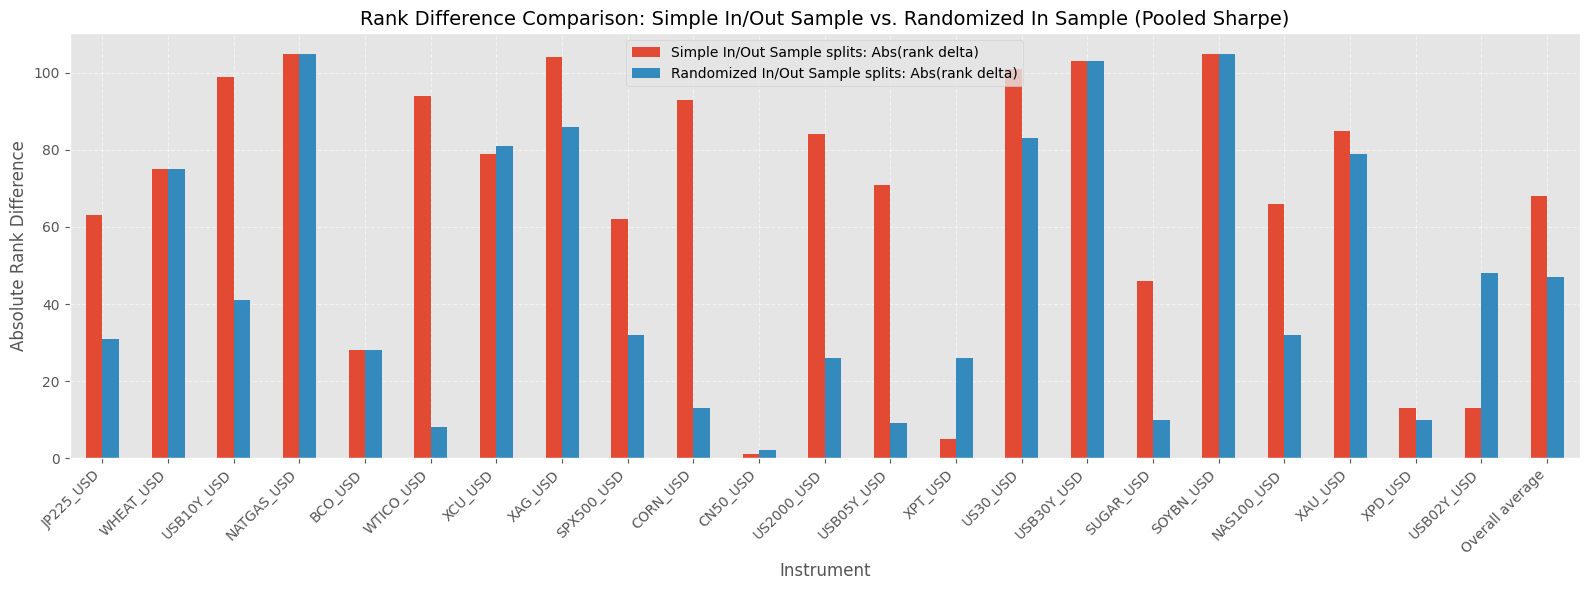

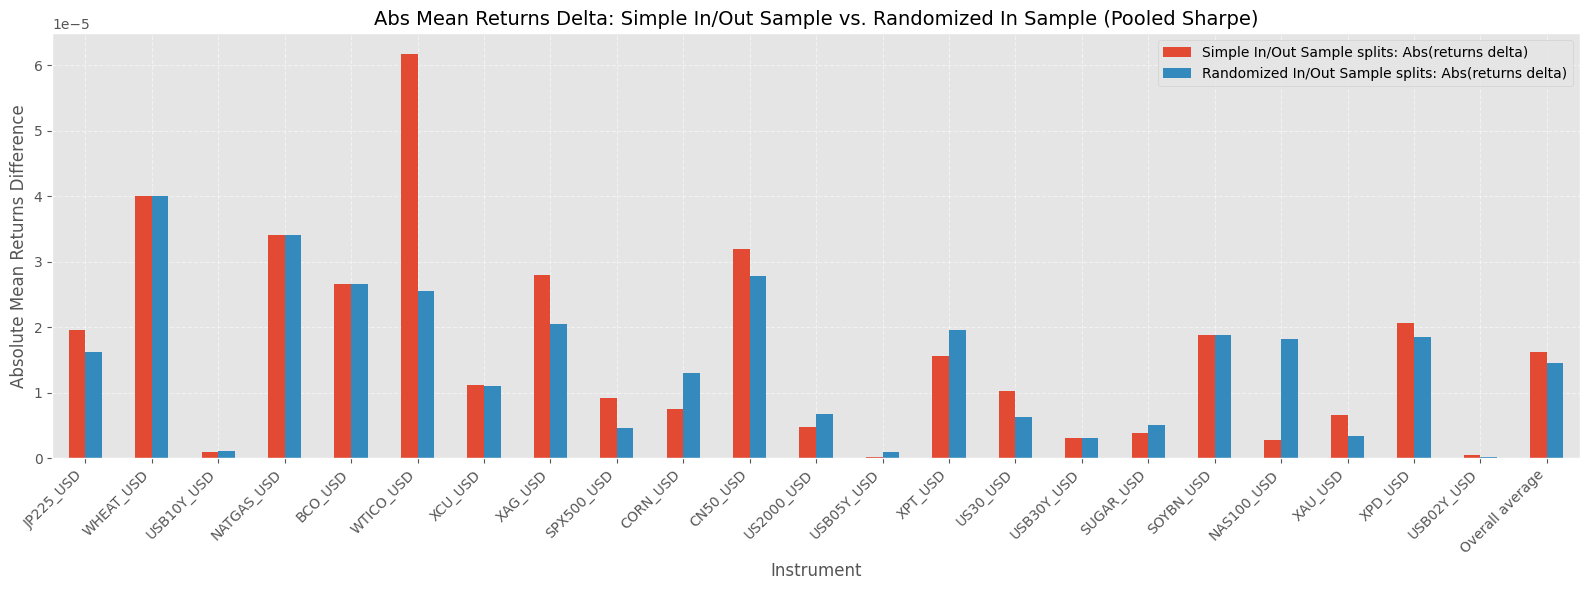

In [9]:
bt.plot_compare(df_compare)

<h4><u>Statistical Comparison: Randomized vs. Simple In/Out Splits</u></h4>

<p>
To evaluate whether the <b>randomized pooled sampling approach</b> improves generalization compared to the standard fixed in/out split, we conducted two one-sided Welch’s t-tests.
</p>

<ol>
  <li>
    <b>Ranking Stability Test</b><br>
    This test compares the average absolute change in Sharpe-based rank (<code>rank_sharpe.diff</code>) between in-sample and out-of-sample periods.
    <ul>
      <li><i>Null Hypothesis:</i> No improvement from randomized sampling.</li>
      <li><i>Alternative Hypothesis:</i> Randomized sampling yields smaller rank deltas, indicating more stable strategy performance.</li>
      <li><i>Method:</i> Welch’s t-test with <code>alternative='less'</code>.</li>
    </ul>
  </li>

  <li>
    <b>Mean Return Stability Test</b><br>
    This test compares the absolute change in mean returns (<code>returns_mean.diff</code>) across the two sampling methods.
    <ul>
      <li><i>Null Hypothesis:</i> No difference in return stability between methods.</li>
      <li><i>Alternative Hypothesis:</i> Randomized method yields smaller return differences out-of-sample.</li>
      <li><i>Unit:</i> Results are expressed in basis points (bps) for interpretability.</li>
    </ul>
  </li>
</ol>

<p>
Both tests use <code>equal_var=False</code> to account for unequal variances (Welch’s correction). The table below summarizes the results, including:
</p>

<ul>
  <li>Average absolute differences under each method</li>
  <li>t-statistics and p-values assessing the statistical significance of observed improvements</li>
</ul>

<p>
This statistical analysis helps validate whether the performance improvements observed through randomized evaluation are significant and not due to chance.
</p>


In [10]:
df_tstat = bt.ttest(df_top_in_out_rand, df_top_inout)

t-statistic Ranking: -1.9699
p-value Ranking: 0.0277
t-statistic Mean: -0.4035
p-value Mean: 0.3444


<hr>
<h4><u><b>Statistical Evaluation of Strategy Generalization: Randomized vs. Simple In/Out Splits</b></u></h4>

<p>
This section compares the generalization ability of trading strategies selected using two methods:
</p>
<ul>
  <li><b>Simple In/Out Sample Splits</b>: Traditional 80/20 split between training and test sets.</li>
  <li><b>Randomized In/Out Sample Splits</b>: Strategy parameters selected based on pooled Sharpe ratios from randomized in-sample folds.</li>
</ul>

<p>
<b>Mean Return Stability:</b><br>
The average absolute difference in mean returns (in basis points) between in- and out-of-sample was <b>0.1627</b> bps using the simple split, and slightly lower at <b>0.1461</b> bps with randomized sampling. However, this difference was <b>not statistically significant</b> (t-statistic = -0.40, p = 0.3444). The lack of significance could be due to an overall absence of exploitable trends (identified by the MACD indicator) in some of the out-of-sample periods, rather than overfitting per se.
</p>

<p>
<b>Sharpe Rank Stability:</b><br>
The absolute difference in Sharpe-based ranking dropped from <b>67.95</b> (simple split) to <b>46.95</b> (randomized), a <b>statistically significant improvement</b> (t-statistic = -1.97, p = 0.0277). This indicates that the randomized selection method produces more stable and robust parameter rankings when tested out-of-sample.
</p>

<p>
<h4 style="text-align: left;"><b> Conclusion </b></h4>
While the mean return deltas were statistically similar, the significant reduction in ranking instability strongly supports the use of randomized parameter selection. This approach mitigates overfitting risk and leads to more generalizable strategy choices across financial instruments.
</p>


In [11]:
df_tstat

,Abs (Rank delta),Abs (Mean Returns delta) - bps
Randomized In/Out Sample splits,46.954545,0.146050
Simple In/Out Sample splits,67.954545,0.162741
tstat,-1.969864,-0.403544
pvalue,0.027736,0.344392


<hr>

<h2 style="text-align: center;"><b>Appendix</b></h2>

<h4> <b> Appendix 1 </b> <h4>
<h4><u><b>Table</b>: Descriptive Stats - Full details</u></h4>

<p>
The table below presents the source data used in the study. The study utilized hourly time series across 22 CFD instruments over a five-year period (2020–2024). Each instrument's total number of valid hourly observations per year is shown in the table.
</p>

In [12]:
bt.descstats_details

inst,BCO_USD,CN50_USD,CORN_USD,JP225_USD,NAS100_USD,NATGAS_USD,SOYBN_USD,SPX500_USD,SUGAR_USD,US2000_USD,US30_USD,USB02Y_USD,USB05Y_USD,USB10Y_USD,USB30Y_USD,WHEAT_USD,WTICO_USD,XAG_USD,XAU_USD,XCU_USD,XPD_USD,XPT_USD
no yrs,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
average observations/year,5634.0,5165.2,4703.0,5894.0,5882.0,5879.6,4724.2,5885.6,2477.8,5880.6,5883.8,5546.8,5857.6,5891.0,5876.2,4712.0,5896.8,5893.4,5893.8,5893.6,5680.8,5712.4
min observations/year,5605.0,5100.0,4626.0,5819.0,5814.0,5814.0,4652.0,5830.0,2462.0,5819.0,5819.0,4889.0,5807.0,5828.0,5790.0,4653.0,5844.0,5838.0,5837.0,5840.0,5317.0,5316.0
max observations/year,5671.0,5200.0,4746.0,5930.0,5922.0,5937.0,4784.0,5922.0,2493.0,5922.0,5922.0,5902.0,5905.0,5919.0,5917.0,4784.0,5928.0,5924.0,5923.0,5931.0,5912.0,5913.0


<h4> <b> Appendix 2 </b> <h4>
<h4> <u> <b> Table</b>: Comparison of Backtest Results Between In & Out of Sample from Simple In/Out Sample Splits  </u> </h4>

<p>
The table below presents the evaluation of the top-performing MACD parameter set (selected based on in-sample Sharpe ratio) for each of 21 CFD instruments. The analysis includes the in-sample and out-of-sample values of Sharpe ratios, rank positions, and mean returns, followed by their absolute differences. These metrics allow us to assess both the quality and stability of strategy performance when deployed on unseen data.
</p>

<ul>
  <li><b>sharpe.in / sharpe.out</b> — Sharpe ratio computed on in-sample and out-of-sample data, respectively.</li>
  <li><b>rank_sharpe.in / rank_sharpe.out</b> — Rank of the parameter based on Sharpe ratio in in-sample and out-of-sample contexts (lower is better).</li>
  <li><b>returns_mean.in / returns_mean.out</b> — Mean return in in-sample and out-of-sample periods.</li>
  <li><b>sharpe.diff</b> — Absolute difference between in-sample and out-of-sample Sharpe ratios.</li>
  <li><b>rank_sharpe.diff</b> — Absolute change in Sharpe-based rank.</li>
  <li><b>returns_mean.diff</b> — Absolute difference in mean return between in and out of sample.</li>
  <li><b>returns_mean.p</b> — p-value from a two-sample t-test assessing whether the difference in mean returns is statistically significant.</li>
</ul>

<p>

In [13]:
df_top_inout

,params,sharpe.in,sharpe.out,rank_sharpe.in,rank_sharpe.out,returns_mean.in,returns_mean.out,sharpe.diff,rank_sharpe.diff,returns_mean.diff,returns_mean.p
instrument,,,,,,,,,,,
JP225_USD,"[""['240', '720', '72', '225']""]",0.004711,0.013447,106.0,43.0,6.950458e-06,2.649904e-05,0.008736,63.0,1.954859e-05,0.98
WHEAT_USD,"[""['24', '120', '24']""]",0.008591,-0.014891,106.0,31.0,1.659663e-05,-2.340557e-05,0.023482,75.0,4.000220e-05,0.95
USB10Y_USD,"[""['240', '720', '72', '10']""]",0.000433,0.002823,106.0,7.0,1.528954e-07,1.135596e-06,0.002390,99.0,9.827007e-07,1.00
NATGAS_USD,"[""['24', '120', '24']""]",0.008819,-0.003512,106.0,1.0,2.375278e-05,-1.035735e-05,0.012331,105.0,3.411012e-05,0.97
BCO_USD,"[""['24', '120', '24']""]",0.008864,-0.002281,106.0,78.0,2.351267e-05,-3.139949e-06,0.011145,28.0,2.665262e-05,0.96
WTICO_USD,"[""['240', '720', '24']""]",0.008091,-0.018425,106.0,12.0,2.650630e-05,-3.530611e-05,0.026516,94.0,6.181241e-05,0.93
XCU_USD,"[""['240', '720', '72']""]",0.003516,0.010190,106.0,27.0,5.203664e-06,1.641711e-05,0.006674,79.0,1.121344e-05,0.98
XAG_USD,"[""['24', '120', '72']""]",0.014140,-0.003381,106.0,2.0,2.273127e-05,-5.301258e-06,0.017521,104.0,2.803253e-05,0.96
SPX500_USD,"[""['240', '720', '72', '500']""]",0.005192,-0.000764,106.0,44.0,8.425033e-06,-7.028965e-07,0.005956,62.0,9.127930e-06,0.98


<h4> <b> Appendix 3 </b> <h4>
<h4><u><b>Table</b>: Comparison of Strategy Robustness — Simple vs. Randomized Evaluation</u></h4>

<p>
The table and charts below compare the generalization performance of MACD strategy parameters selected via two methods:
</p>
<ul>
  <li><b>Simple In/Out Sample Split</b> — Selecting the top parameter from a single fixed in-sample period.</li>
  <li><b>Randomized In-Sample Folds (Pooled Sharpe)</b> — Selecting the top parameter based on pooled performance across randomized splits of the in-sample data.</li>
</ul>

<p>
Each row in the table corresponds to a financial instrument. The columns show:
</p>
<ul>
  <li><b>Abs(rank delta)</b>: The absolute difference in Sharpe-based rank from in-sample to out-of-sample.</li>
  <li><b>Abs(returns delta)</b>: The absolute difference in mean return from in-sample to out-of-sample.</li>
  <li><b>Improved Ranking</b>: Whether the randomized method led to a lower rank difference compared to the simple split.</li>
  <li><b>Improved Abs Returns Delta</b>: Whether the randomized method reduced the out-of-sample return error.</li>
</ul>

<p>


In [14]:
df_top_in_out_rand

,params,sharpe.in,sharpe.out,rank_sharpe.in,rank_sharpe.out,returns_mean.in,returns_mean.out,sharpe.diff,rank_sharpe.diff,returns_mean.diff,returns_mean.p
JP225_USD,"[""['96', '120', '72', '225']""]",0.001912,0.011049,41.0,10.0,2.474585e-06,1.876504e-05,0.009137,31.0,1.629045e-05,0.98
WHEAT_USD,"[""['24', '120', '24']""]",0.008591,-0.014891,106.0,31.0,1.659663e-05,-2.340557e-05,0.023482,75.0,4.000220e-05,0.95
USB10Y_USD,"[""['24', '120', '24', '10']""]",-0.001485,0.002616,44.0,3.0,-3.622369e-07,7.437681e-07,0.004101,41.0,1.106005e-06,1.00
NATGAS_USD,"[""['24', '120', '24']""]",0.008819,-0.003512,106.0,1.0,2.375278e-05,-1.035735e-05,0.012331,105.0,3.411012e-05,0.97
BCO_USD,"[""['24', '120', '24']""]",0.008864,-0.002281,106.0,78.0,2.351267e-05,-3.139949e-06,0.011145,28.0,2.665262e-05,0.96
WTICO_USD,"[""['24', '120', '24']""]",0.007457,-0.003495,102.0,94.0,2.051805e-05,-4.997849e-06,0.010952,8.0,2.551590e-05,0.97
XCU_USD,"[""['240', '600', '72']""]",0.003457,0.010082,105.0,24.0,5.118883e-06,1.609445e-05,0.006625,81.0,1.097556e-05,0.99
XAG_USD,"[""['24', '480', '24']""]",0.013538,0.000163,103.0,17.0,2.078507e-05,2.424579e-07,0.013375,86.0,2.054261e-05,0.97
SPX500_USD,"[""['240', '480', '24', '500']""]",0.003509,0.000149,80.0,48.0,4.687203e-06,1.233696e-07,0.003360,32.0,4.563833e-06,0.99
CORN_USD,"[""['240', '720', '72']""]",-0.002722,0.004519,93.0,106.0,-5.294119e-06,7.747069e-06,0.007241,13.0,1.304119e-05,0.98


<h4> <b> Appendix 4 </b> <h4>
<h4><u><b>Table</b>: Comparison of Strategy Robustness — Simple vs. Randomized Evaluation</u></h4>

<p>
The table and charts below compare the generalization performance of MACD strategy parameters selected via two methods:
</p>
<ul>
  <li><b>Simple In/Out Sample Split</b> — Selecting the top parameter from a single fixed in-sample period.</li>
  <li><b>Randomized In-Sample Folds (Pooled Sharpe)</b> — Selecting the top parameter based on pooled performance across randomized splits of the in-sample data.</li>
</ul>

<p>
Each row in the table corresponds to a financial instrument. The columns show:
</p>
<ul>
  <li><b>Abs(rank delta)</b>: The absolute difference in Sharpe-based rank from in-sample to out-of-sample.</li>
  <li><b>Abs(returns delta)</b>: The absolute difference in mean return from in-sample to out-of-sample.</li>
  <li><b>Improved Ranking</b>: Whether the randomized method led to a lower rank difference compared to the simple split.</li>
  <li><b>Improved Abs Returns Delta</b>: Whether the randomized method reduced the out-of-sample return error.</li>
</ul>

In [15]:
df_compare

,Simple In/Out Sample splits: Abs(rank delta),Randomized In/Out Sample splits: Abs(rank delta),In-Sample Rank Diff,Randomized Pooled Rank Diff,Randomized In/Out Sample splits: Abs(returns delta),Simple In/Out Sample splits: Abs(returns delta),Improved Ranking,Improved Abs Returns Delta
JP225_USD,63.000000,31.000000,1.954859e-05,1.629045e-05,1.629045e-05,1.954859e-05,True,True
WHEAT_USD,75.000000,75.000000,4.000220e-05,4.000220e-05,4.000220e-05,4.000220e-05,False,False
USB10Y_USD,99.000000,41.000000,9.827007e-07,1.106005e-06,1.106005e-06,9.827007e-07,True,False
NATGAS_USD,105.000000,105.000000,3.411012e-05,3.411012e-05,3.411012e-05,3.411012e-05,False,False
BCO_USD,28.000000,28.000000,2.665262e-05,2.665262e-05,2.665262e-05,2.665262e-05,False,False
WTICO_USD,94.000000,8.000000,6.181241e-05,2.551590e-05,2.551590e-05,6.181241e-05,True,True
XCU_USD,79.000000,81.000000,1.121344e-05,1.097556e-05,1.097556e-05,1.121344e-05,False,True
XAG_USD,104.000000,86.000000,2.803253e-05,2.054261e-05,2.054261e-05,2.803253e-05,True,True
SPX500_USD,62.000000,32.000000,9.127930e-06,4.563833e-06,4.563833e-06,9.127930e-06,True,True
CORN_USD,93.000000,13.000000,7.483987e-06,1.304119e-05,1.304119e-05,7.483987e-06,True,False
